In [218]:
using Pkg
Pkg.activate("ad_env")
Pkg.instantiate()
using DataFrames
using CairoMakie
using Statistics

  Activating project at `c:\Users\Jakub\Dokumenty\Projects\ADwUB_lipidy\ad_env`


In [219]:
kalibracja = DataFrame([[0.259, 0.23, 0.214, 0.28, 0.468, 0.424, 0.219], [0.438, 1.136, 0.455, 0.373, 0.946, 0.561, 0.61], [0.39,0.228,0.439,0.444,0.208,0.278,0.466],[0.226,0.382,0.218,0.266,0.32,0.334,0.385]], [:g1_s1, :g1_s2, :g2_s1, :g2_s2])
println(kalibracja)

7×4 DataFrame
 Row │ g1_s1    g1_s2    g2_s1    g2_s2   
     │ Float64  Float64  Float64  Float64 
─────┼────────────────────────────────────
   1 │   0.259    0.438    0.39     0.226
   2 │   0.23     1.136    0.228    0.382
   3 │   0.214    0.455    0.439    0.218
   4 │   0.28     0.373    0.444    0.266
   5 │   0.468    0.946    0.208    0.32
   6 │   0.424    0.561    0.278    0.334
   7 │   0.219    0.61     0.466    0.385


In [220]:
test = DataFrame([[0.335, 0.291, 0.379], [1.059, missing, missing], [0.588, 0.362, 0.393], [0.262, 0.252, 0.278]], [:g1_s1, :g1_s2, :g2_s1, :g2_s2])
println(test)

3×4 DataFrame
 Row │ g1_s1     g1_s2        g2_s1     g2_s2    
     │ Float64?  Float64?     Float64?  Float64? 
─────┼───────────────────────────────────────────
   1 │    0.335        1.059     0.588     0.262
   2 │    0.291  missing         0.362     0.252
   3 │    0.379  missing         0.393     0.278


In [221]:
for c in names(kalibracja)
    test[!, c] .-= kalibracja[1, c]
    kalibracja[!, c] .-= kalibracja[1, c]
end
kalibracja[!, :g1_średnia_wiersze] = mean(Matrix(kalibracja[!, [:g1_s1, :g1_s2]]), dims=2)[:, 1]
kalibracja[!, :g2_średnia_wiersze] = mean(Matrix(kalibracja[!, [:g2_s1, :g2_s2]]), dims=2)[:, 1]
kalibracja[!, :g1g2_średnia_wiersze] = mean(Matrix(kalibracja[!, [:g2_s1, :g2_s2, :g1_s1, :g1_s2]]), dims=2)[:, 1]
kalibracja[!,:próbka] = [0,1,2,4,6,8,10]
println(kalibracja)
println(test)

7×8 DataFrame
 Row │ g1_s1    g1_s2    g2_s1    g2_s2    g1_średnia_wiersze  g2_średnia_wiersze  g1g2_średnia_wiersze  próbka 
     │ Float64  Float64  Float64  Float64  Float64             Float64             Float64               Int64  
─────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │   0.0      0.0      0.0      0.0                0.0                 0.0                  0.0           0
   2 │  -0.029    0.698   -0.162    0.156              0.3345             -0.003                0.16575       1
   3 │  -0.045    0.017    0.049   -0.008             -0.014               0.0205               0.00325       2
   4 │   0.021   -0.065    0.054    0.04              -0.022               0.047                0.0125        4
   5 │   0.209    0.508   -0.182    0.094              0.3585             -0.044                0.15725       6
   6 │   0.165    0.123   -0.112    0.108              0.144              -0.002       

In [222]:
function regresja_liniowa(x,y)
    x_śr = mean(x)
    y_śr = mean(y)
    a = sum((x .- x_śr).*(y .- y_śr)) / sum((x .- x_śr).^2)
    b = y_śr - a*x_śr
    r2 = sum((y_śr .- (a .* x .+ b)) .^ 2) / sum((y_śr .- y) .^ 2)
    return [a,b,r2]
end

regresja_liniowa (generic function with 1 method)

In [223]:
function wykres(ax,y,x,test_x)
    a, b, r2 = regresja_liniowa(x,y)
    linspace = [minimum(skipmissing(vcat(x, test_x))),maximum(skipmissing(vcat(x, test_x)))]
    test_y = test_x.* a .+ b
    vlines!(ax, test_x, linewidth=1.2,linestyle=:dash,color=:red, alpha=0.7)
    lines!(ax,linspace,a.*linspace.+b, linestyle=(:dash,:dense), label="r²="*string(round(r2, digits=3)),linewidth=4)
    scatter!(ax, x, y, markersize=13,color=:lightblue)
    scatter!(ax,test_x,test_y,markersize=17,marker=:x,color=:red)
    axislegend(ax, position=:rb, framevisible=false)
end

wykres (generic function with 1 method)

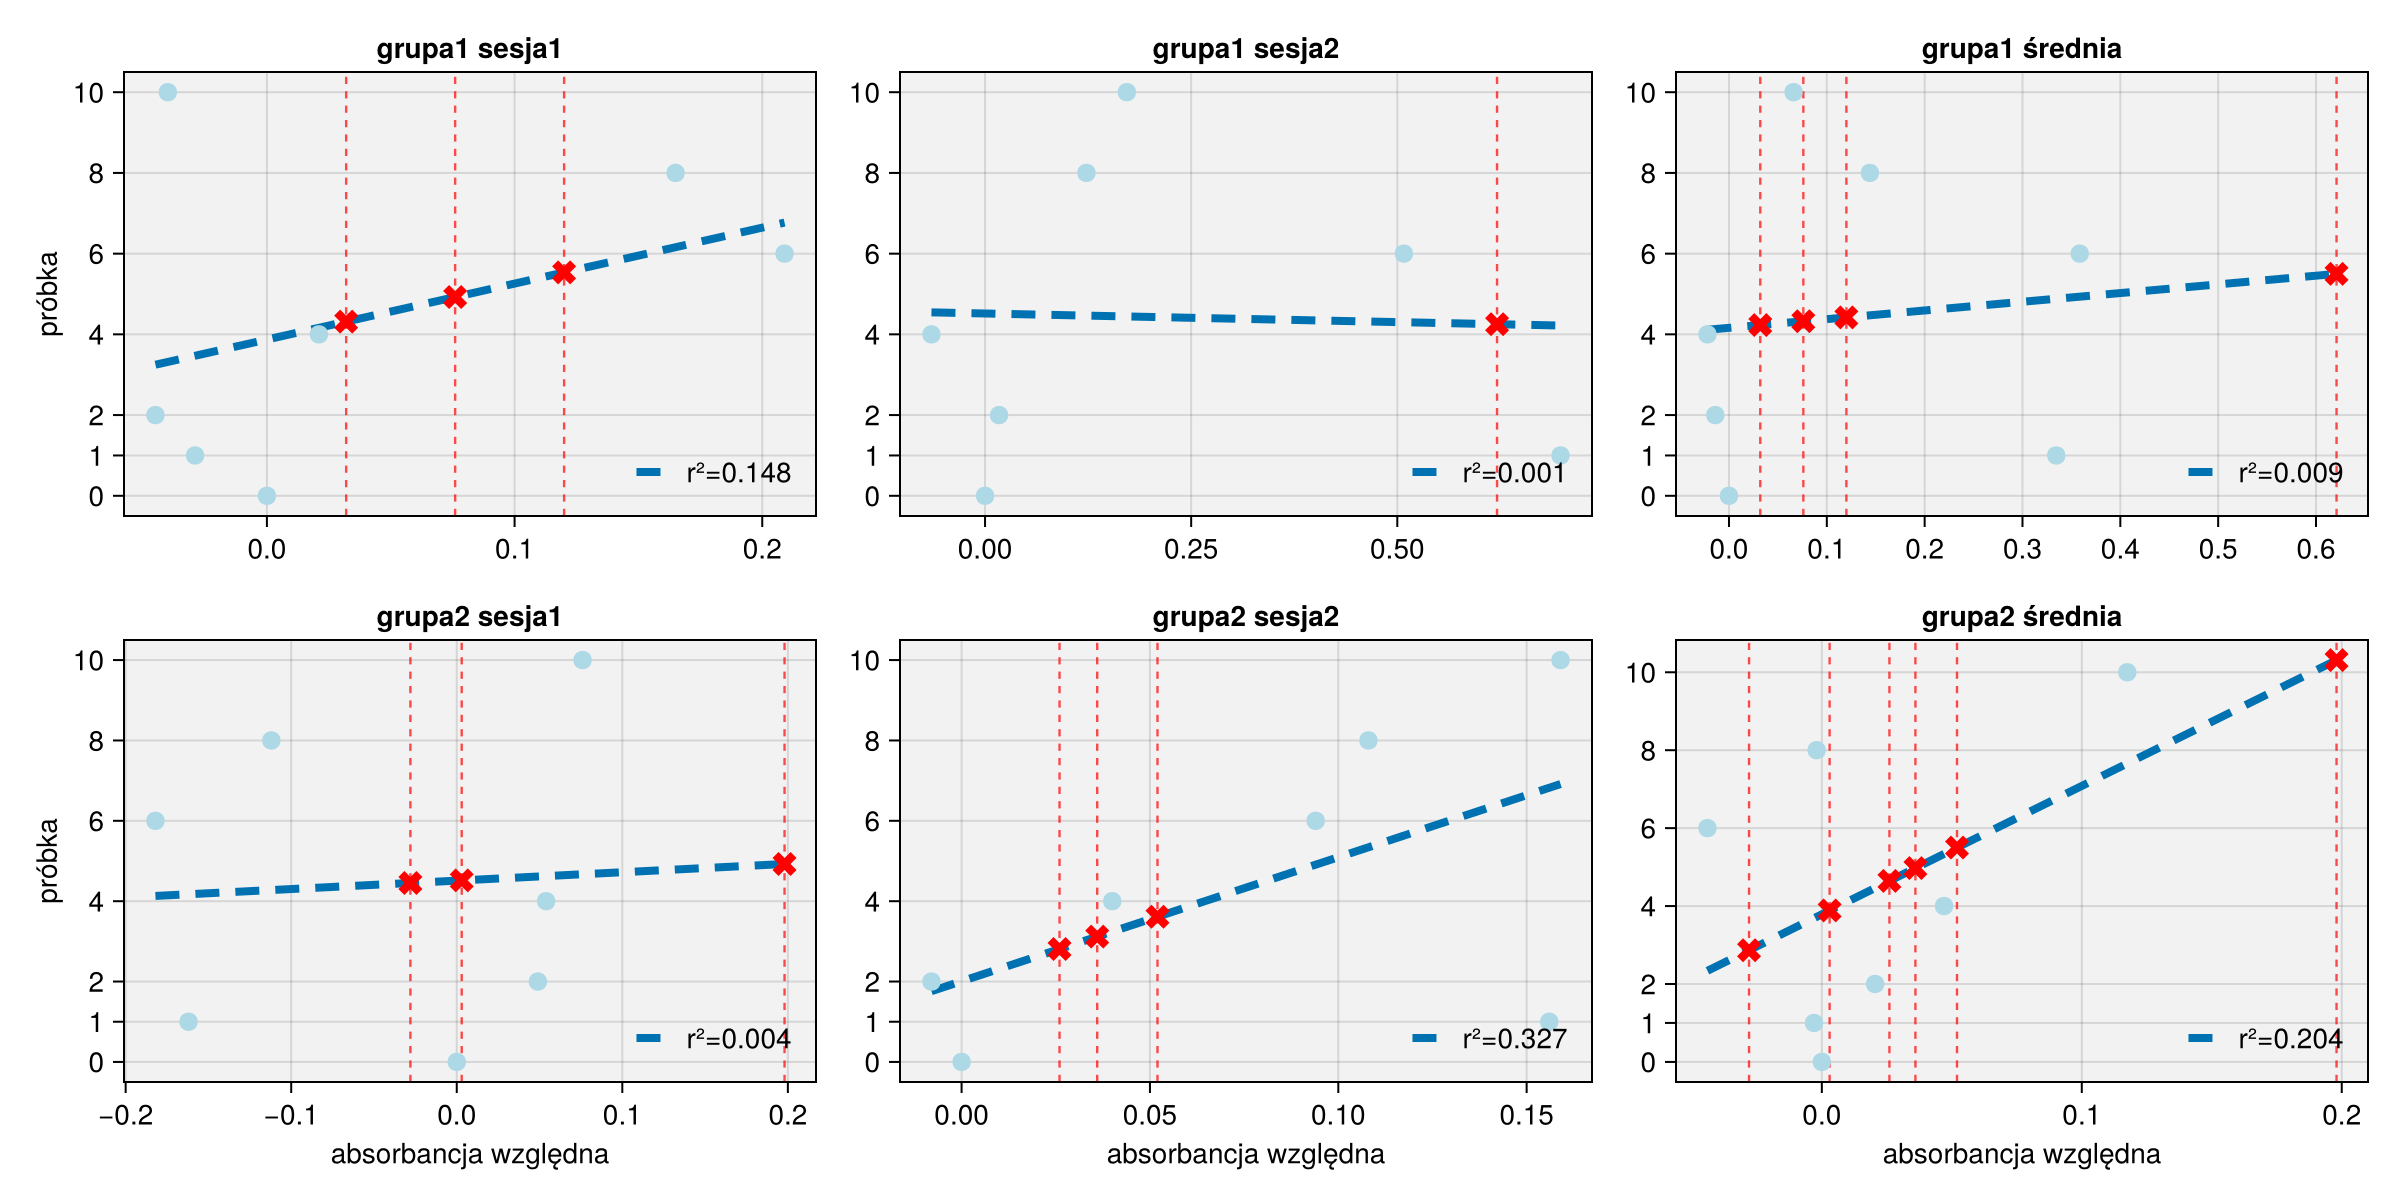

In [224]:
bkg_col = :gray95
fig = Figure(size=(1200, 600))
ax = Axis(fig[1, 1], title="grupa1 sesja1", backgroundcolor=bkg_col, yticks=kalibracja[:, :próbka], ylabel="próbka")
wykres(ax, kalibracja[:, :próbka], kalibracja[:, :g1_s1], test[:,:g1_s1])
ax = Axis(fig[1, 2], title="grupa1 sesja2", backgroundcolor=bkg_col, yticks=kalibracja[:,:próbka])
wykres(ax, kalibracja[:, :próbka], kalibracja[:, :g1_s2], test[:,:g1_s2])
ax = Axis(fig[2, 1], title="grupa2 sesja1", backgroundcolor=bkg_col, yticks=kalibracja[:, :próbka], ylabel="próbka", xlabel="absorbancja względna")
wykres(ax, kalibracja[:, :próbka], kalibracja[:, :g2_s1], test[:, :g2_s1])
ax = Axis(fig[2, 2], title="grupa2 sesja2", backgroundcolor=bkg_col, yticks=kalibracja[:, :próbka], xlabel="absorbancja względna")
wykres(ax, kalibracja[:, :próbka], kalibracja[:, :g2_s2], test[:, :g2_s2])
ax = Axis(fig[1, 3], title="grupa1 średnia", backgroundcolor=bkg_col, yticks=kalibracja[:, :próbka])
wykres(ax, kalibracja[:, :próbka], kalibracja[:, :g1_średnia_wiersze], vcat(test[:, :g1_s1],test[:,:g1_s2]))
ax = Axis(fig[2, 3], title="grupa2 średnia", backgroundcolor=bkg_col, yticks=kalibracja[:, :próbka], xlabel="absorbancja względna")
wykres(ax, kalibracja[:, :próbka], kalibracja[:, :g2_średnia_wiersze], vcat(test[:, :g2_s1], test[:, :g2_s2]))
fig

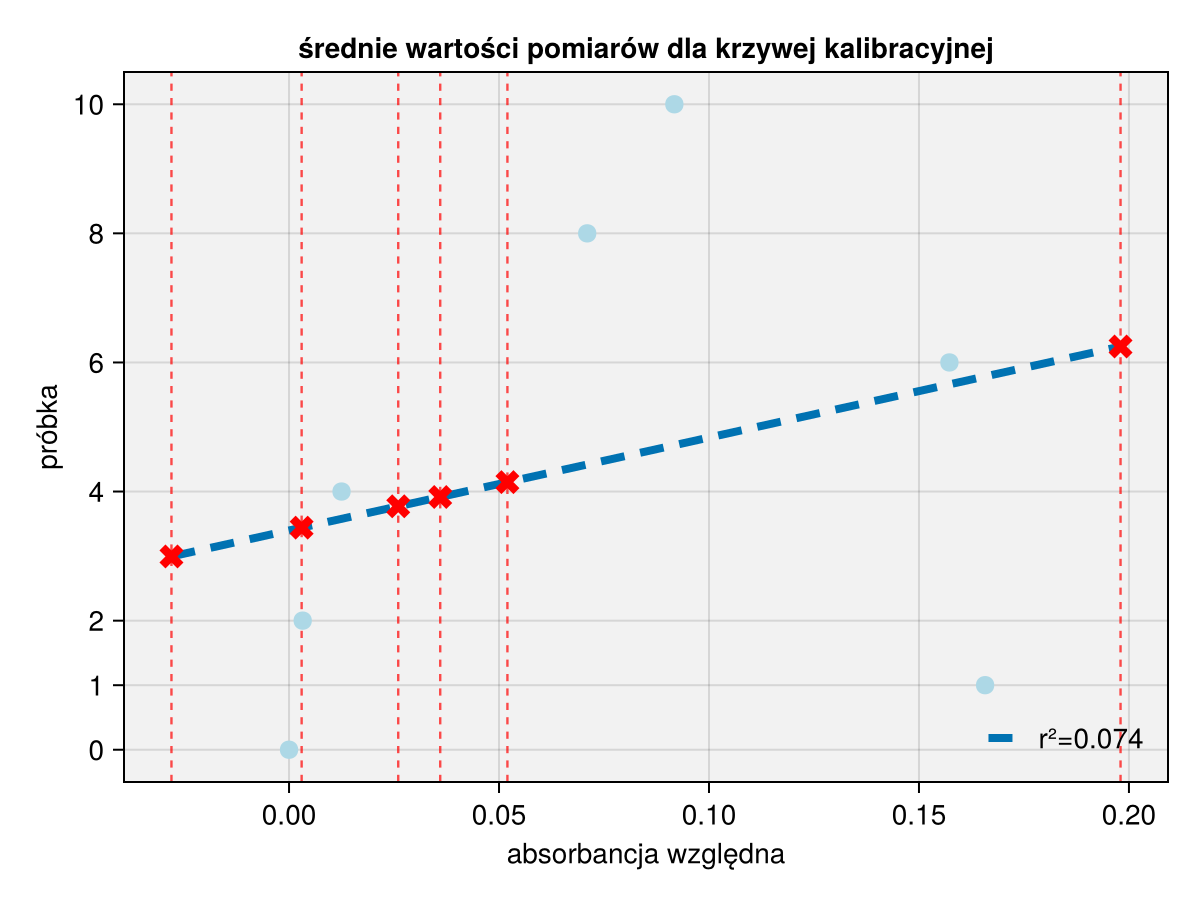

In [225]:
fig = Figure()
ax = Axis(fig[1, 1], title="średnie wartości pomiarów dla krzywej kalibracyjnej", backgroundcolor=bkg_col, yticks=kalibracja[:, :próbka],xlabel="absorbancja względna", ylabel="próbka")
wykres(ax, kalibracja[:, :próbka], kalibracja[:, :g1g2_średnia_wiersze], vcat(test[:, :g2_s1], test[:, :g2_s2]))
fig

### Odrzucenie jednego punktu pomiarowego na serię w celu optymalizacji r^2

In [226]:
function optymalizacja_r2(x,y)
    Int64(maximum(reverse!.([pushfirst!(regresja_liniowa(x[1:end.!=i], y[1:end.!=i]), i) for i in 1:length(x)]))[end])
end

optymalizacja_r2 (generic function with 1 method)

In [ ]:
fig = Figure()
df = DataFrame()
for col in names(kalibracja[:,1:4])
    println(DataFrame([kalibracja[:,col]],[:col]))
    #DataFrame([i != optymalizacja_r2(col, kalibracja[:, :próbka]) ? col[i] : missing for i in 1:length(col)],[:])
end

ArgumentError: ArgumentError: if the first positional argument to DataFrame constructor is a vector of vectors and the second positional argument is passed then the second argument must be a vector of column names or :auto